# Exploring the momentum/MACD features

Builds the 8-feature panel (`(date, ticker, feature)`) across the 26-ticker ETF universe using `trading_strategies.utils.features`, then looks at distributions, cross-ticker agreement, and time series for a couple of names.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

from trading_strategies.utils.features import MACD_PAIRS, MOMENTUM_LOOKBACKS, StreamingFeatureSet

pd.set_option("display.max_columns", None)

## Load raw prices and build the feature panel

In [2]:
raw = pd.read_parquet("../data/raw.parquet")
raw = raw.sort_values(["ticker", "date"]).set_index("date")
raw.groupby("ticker").size().sort_values()

ticker
BND     4708
IGIB    4708
IWM     4708
IYR     4708
IYT     4708
        ... 
FXI     4708
FXY     4708
GDX     4708
HYG     4708
XLY     4708
Length: 61, dtype: int64

In [3]:
def _features_for_one_ticker(group: pd.DataFrame) -> pd.DataFrame:
    feature_set = StreamingFeatureSet(macd_phi=False)
    rows = [feature_set.update(close) for close in group["close"]]
    return pd.DataFrame(rows, index=group.index)


panel = raw.groupby("ticker", group_keys=True).apply(_features_for_one_ticker)
panel.index.names = ["ticker", "date"]
panel = panel.reorder_levels(["date", "ticker"]).sort_index()

print(panel.shape)
panel.tail()

(287188, 8)


mom_1    mom_21    mom_63   mom_126   mom_252  \
date       ticker                                                     
2025-12-31 XLI    -1.017113  0.638526  0.131218  0.498416  1.166151   
           XLP    -0.876628 -0.650551 -0.133858 -0.735369 -0.188953   
           XLU    -0.819275 -1.020937 -0.504131  0.576823  0.944039   
           XLV    -0.664964 -0.080899  1.123342  1.402418  0.798227   
           XLY    -0.746502  0.191986 -0.114740  0.688489  0.230026   

                   macd_8_24  macd_16_48  macd_32_96  
date       ticker                                     
2025-12-31 XLI      0.937754    1.265371    1.229991  
           XLP     -0.285634   -0.030622   -1.036746  
           XLU     -0.820780   -1.095633   -0.013211  
           XLV      0.489977    1.118609    1.602144  
           XLY      0.644255    1.095102    1.400693

## Sanity checks: NaN warm-up period and distribution per feature

The longest lookback (252d momentum) and MACD's own 252-day std_252(q) normalization window mean each ticker needs ~500 trading days before every feature is populated. The winsorizer (halflife=31) warms up much faster and does not drive this.

In [4]:
nan_counts = panel.isna().sum()
first_fully_valid_date = panel.dropna().index.get_level_values("date").min()
print("NaNs per feature:\n", nan_counts)
print("\nFirst fully-valid date across all tickers/features:", first_fully_valid_date)

NaNs per feature:
 mom_1          3660
mom_21         3660
mom_63         3843
mom_126        7686
mom_252       15372
macd_8_24     19093
macd_16_48    19093
macd_32_96    21106
dtype: int64

First fully-valid date across all tickers/features: 2008-08-29 00:00:00


In [5]:
panel.dropna().describe()

,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
count,266082.000000,266082.000000,266082.000000,266082.000000,266082.000000,266082.000000,266082.000000,266082.000000
mean,0.008547,0.078663,0.150506,0.202727,0.228949,0.108275,0.209725,0.348719
std,0.971952,0.925222,0.917381,0.948380,1.012325,1.066252,1.211462,1.646472
min,-5.408093,-3.956142,-3.815617,-3.479993,-3.928949,-4.477264,-4.809584,-10.849462
25%,-0.575692,-0.543198,-0.488114,-0.472816,-0.500184,-0.655387,-0.813804,-0.884320
50%,0.045517,0.112584,0.167289,0.192162,0.172162,0.184017,0.332409,0.435439
75%,0.637544,0.725377,0.797228,0.863617,0.899871,0.900358,1.182615,1.424899
max,5.445050,4.036534,4.069235,5.483248,12.663425,4.431357,6.476730,10.369670


## Feature correlation

Are the 5 momentum lookbacks and 3 MACD variants actually adding independent information, or mostly redundant?

,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
mom_1,1.000000,0.230013,0.140576,0.104102,0.072009,0.113646,0.051532,0.022951
mom_21,0.230013,1.000000,0.590698,0.435823,0.313120,0.876192,0.738150,0.369774
mom_63,0.140576,0.590698,1.000000,0.693182,0.476051,0.601867,0.799249,0.689728
mom_126,0.104102,0.435823,0.693182,1.000000,0.658025,0.454195,0.672908,0.787307
mom_252,0.072009,0.313120,0.476051,0.658025,1.000000,0.338877,0.526412,0.697302
macd_8_24,0.113646,0.876192,0.601867,0.454195,0.338877,1.000000,0.837561,0.437674
macd_16_48,0.051532,0.738150,0.799249,0.672908,0.526412,0.837561,1.000000,0.777355
macd_32_96,0.022951,0.369774,0.689728,0.787307,0.697302,0.437674,0.777355,1.000000


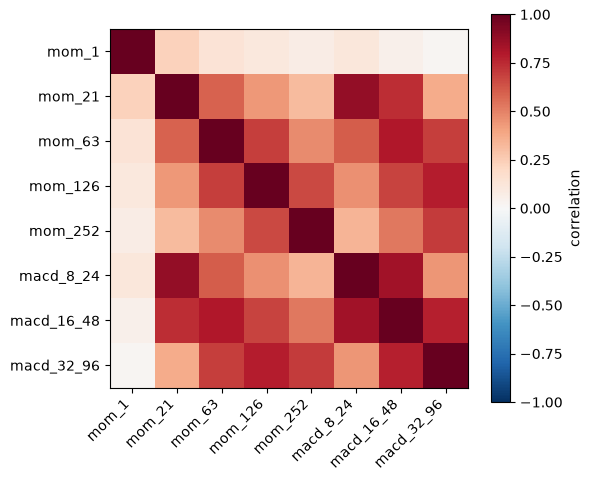

In [6]:
corr = panel.dropna().corr()
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr.columns)), corr.columns)
fig.colorbar(im, ax=ax, label="correlation")
fig.tight_layout()
corr

## Time series for one ticker

Pick a ticker and eyeball the feature time series against price, to check the features move sensibly with visible trends.

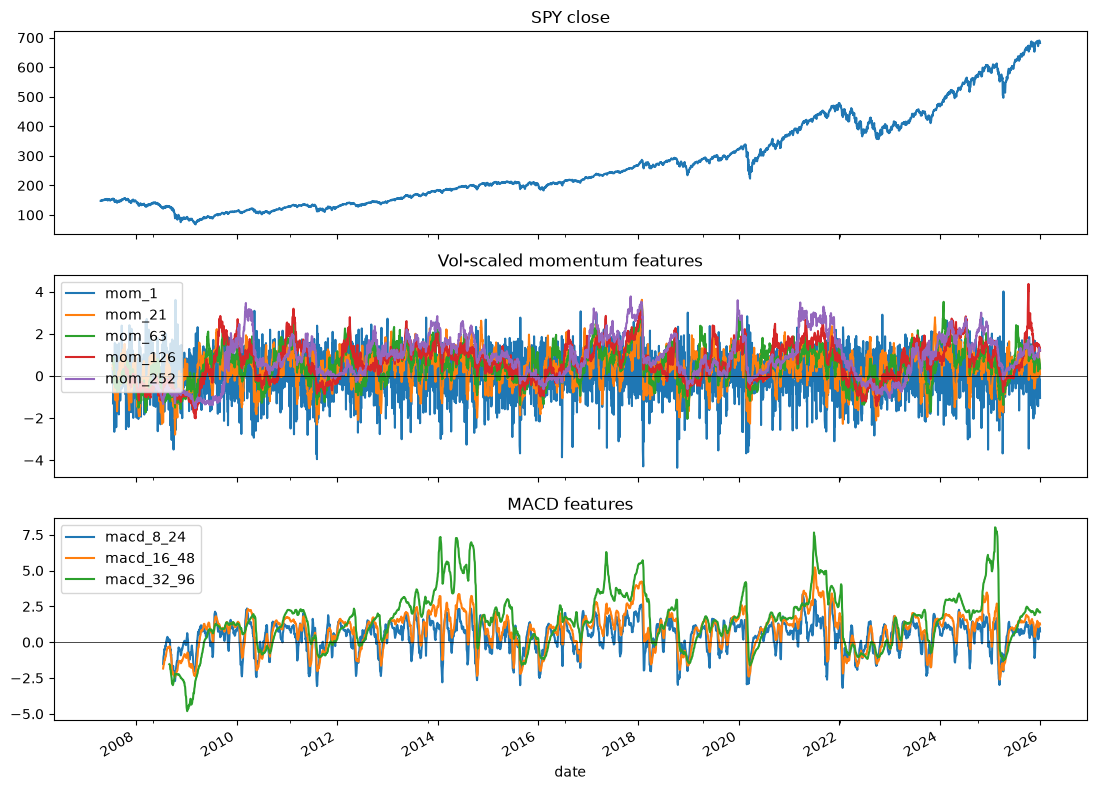

In [7]:
ticker = "SPY"
ticker_features = panel.xs(ticker, level="ticker")
ticker_close = raw.loc[raw["ticker"] == ticker, "close"]

fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)

axes[0].plot(ticker_close.index, ticker_close.values)
axes[0].set_title(f"{ticker} close")

mom_cols = [f"mom_{lb}" for lb in MOMENTUM_LOOKBACKS]
ticker_features[mom_cols].plot(ax=axes[1])
axes[1].set_title("Vol-scaled momentum features")
axes[1].axhline(0, color="black", linewidth=0.5)

macd_cols = [f"macd_{short}_{long}" for short, long in MACD_PAIRS]
ticker_features[macd_cols].plot(ax=axes[2])
axes[2].set_title("MACD features")
axes[2].axhline(0, color="black", linewidth=0.5)

fig.tight_layout()

## Winsorize halflife sensitivity

`winsorize` clips each feature to +/- 5 EWM std around its EWM mean, with `halflife=31` (the default was 252; the sensitivity check below showed clipping barely happens at any halflife tested, so 31 was chosen instead). Build the *raw* (unwinsorized) features once, then run each raw series through a fresh `_Winsorizer` at a few different halflives, and compare:

1. an overlay plot of the clipped series at each halflife against the raw series
2. how often each halflife actually clips anything
3. how correlated the resulting series are across halflives (if ~1.0, the choice barely matters)


In [8]:
from trading_strategies.utils.features import (
    MACD_PAIRS,
    MOMENTUM_LOOKBACKS,
    StreamingMacd,
    StreamingVolScaledMomentum,
    _Winsorizer,
)
from trading_strategies.utils.streaming import EwmMoments

HALFLIVES = [31, 63, 126, 252, 504]
BASELINE_HALFLIFE = 31


def _raw_features_for_one_ticker(group: pd.DataFrame) -> pd.DataFrame:
    features = [
        StreamingVolScaledMomentum(lookback, winsorize=False) for lookback in MOMENTUM_LOOKBACKS
    ] + [StreamingMacd(short, long, winsorize=False) for short, long in MACD_PAIRS]
    rows = []
    for close in group["close"]:
        row = {}
        for feature in features:
            value = feature.update(close)
            if value is not None:
                row[feature.name] = value
        rows.append(row)
    return pd.DataFrame(rows, index=group.index)


def _winsorize_series(raw_series: pd.Series, halflife: float) -> pd.Series:
    winsorizer = _Winsorizer(EwmMoments(halflife=halflife))
    return raw_series.apply(lambda v: winsorizer.apply(v) if pd.notna(v) else v)


# Kept as (ticker, date) here (not reordered like `panel`) so a plain
# groupby(level="ticker") is enough to winsorize each ticker's series
# independently -- reordering to (date, ticker) first would let a naive
# `.apply` see other tickers' feature vector as a "row" and corrupt the EWM.
raw_panel = raw.groupby("ticker", group_keys=True).apply(_raw_features_for_one_ticker)
raw_panel.index.names = ["ticker", "date"]

winsorized_by_halflife = {
    hl: raw_panel.groupby(level="ticker", group_keys=False).apply(
        lambda g, hl=hl: g.apply(lambda col: _winsorize_series(col, hl))
    )
    for hl in HALFLIVES
}

print(raw_panel.shape)


(287188, 8)


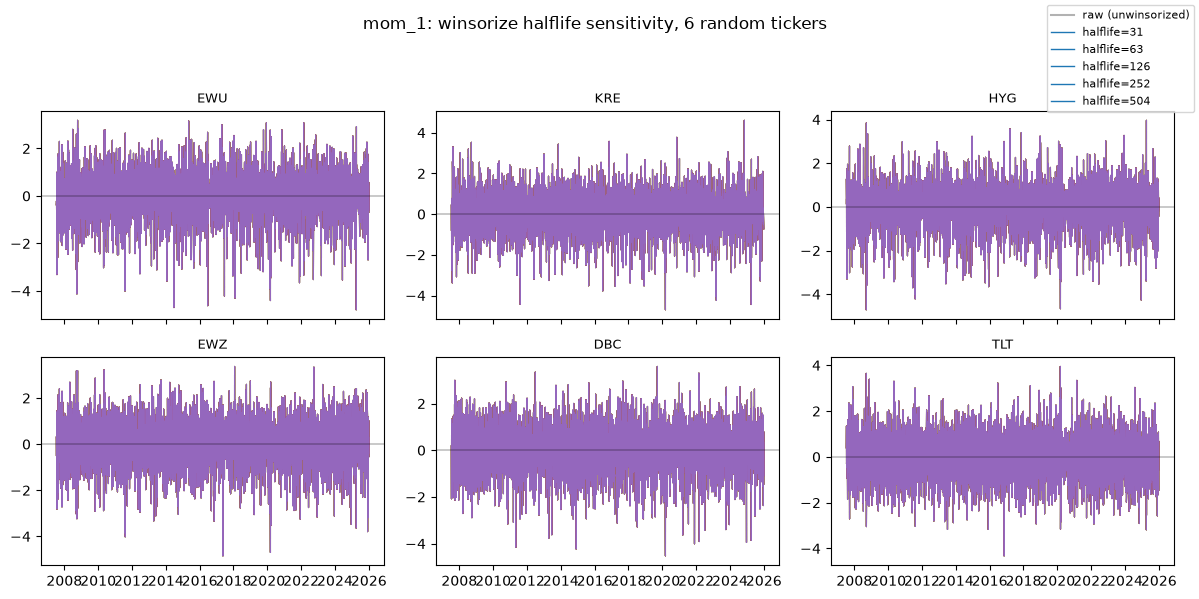

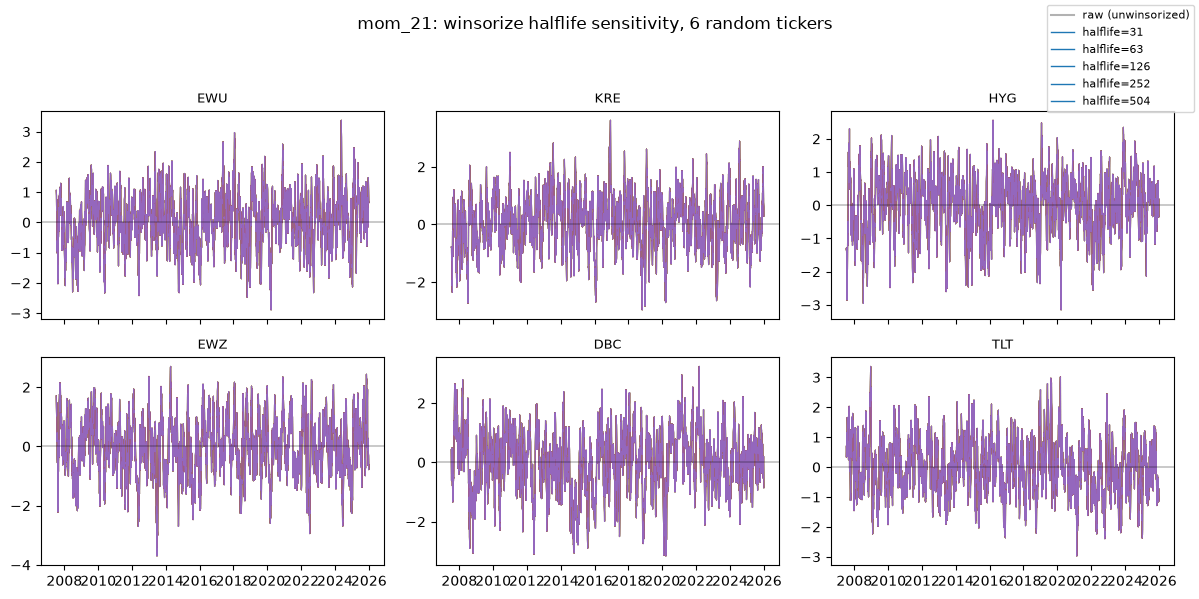

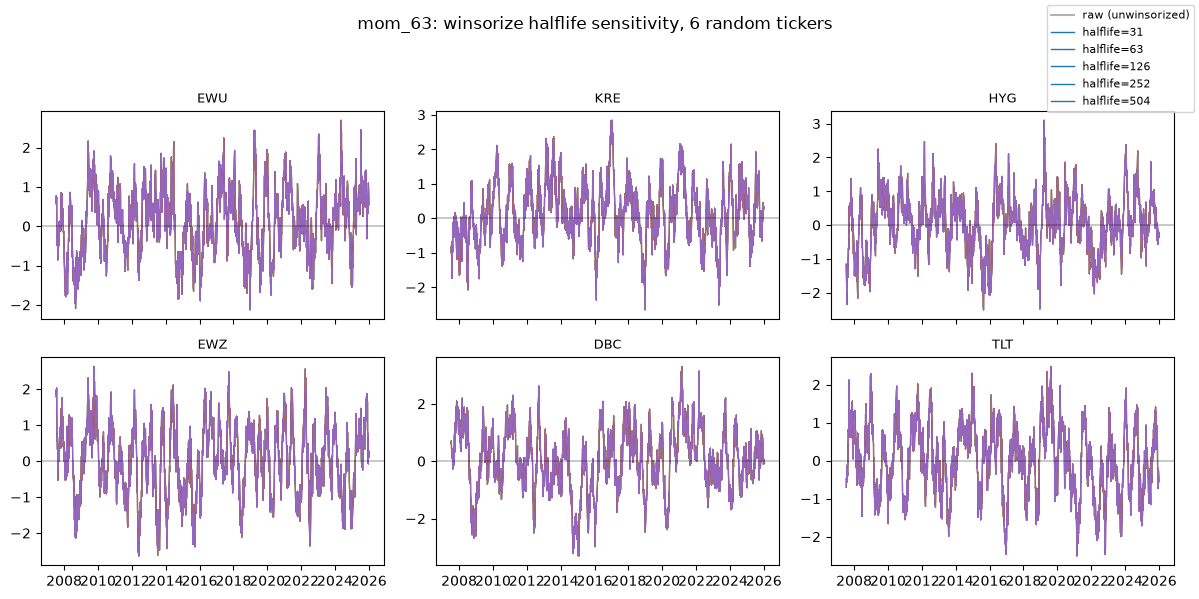

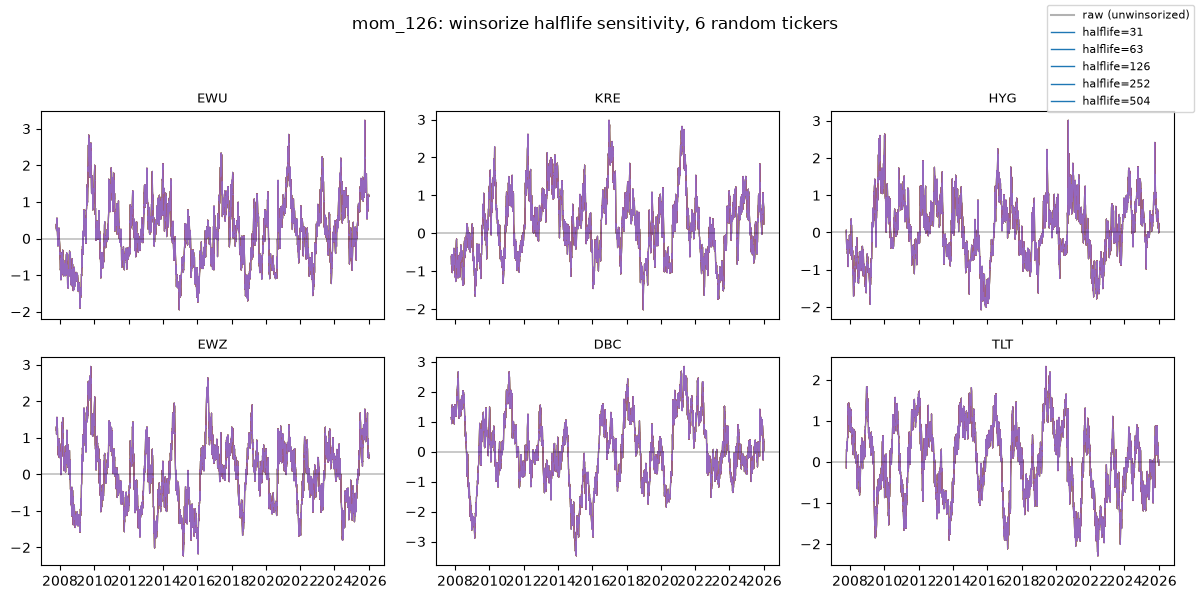

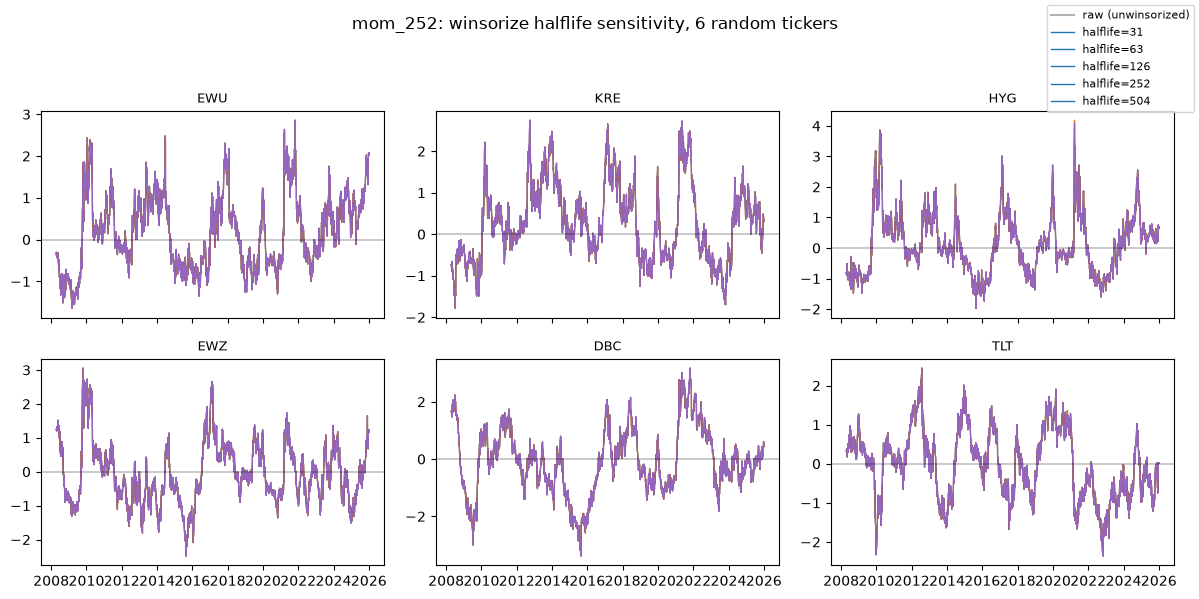

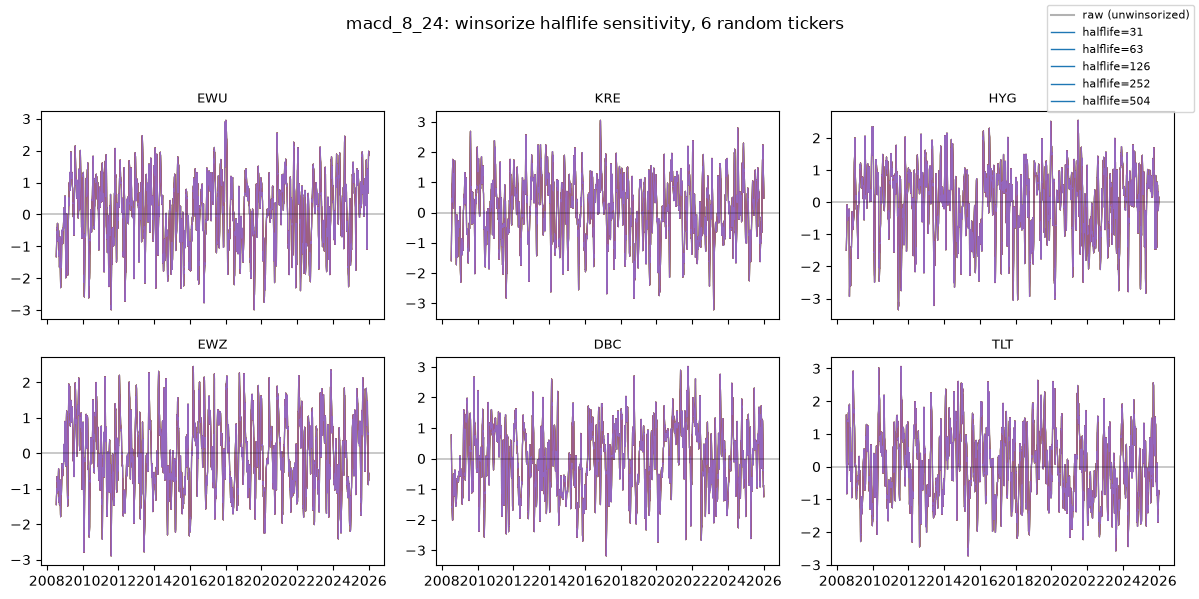

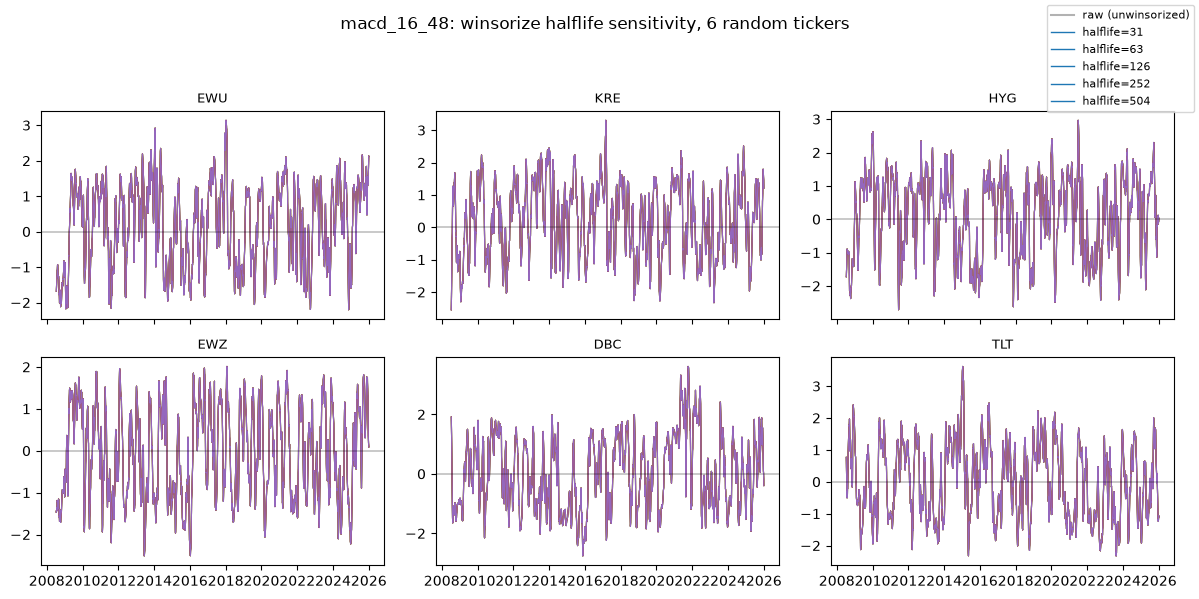

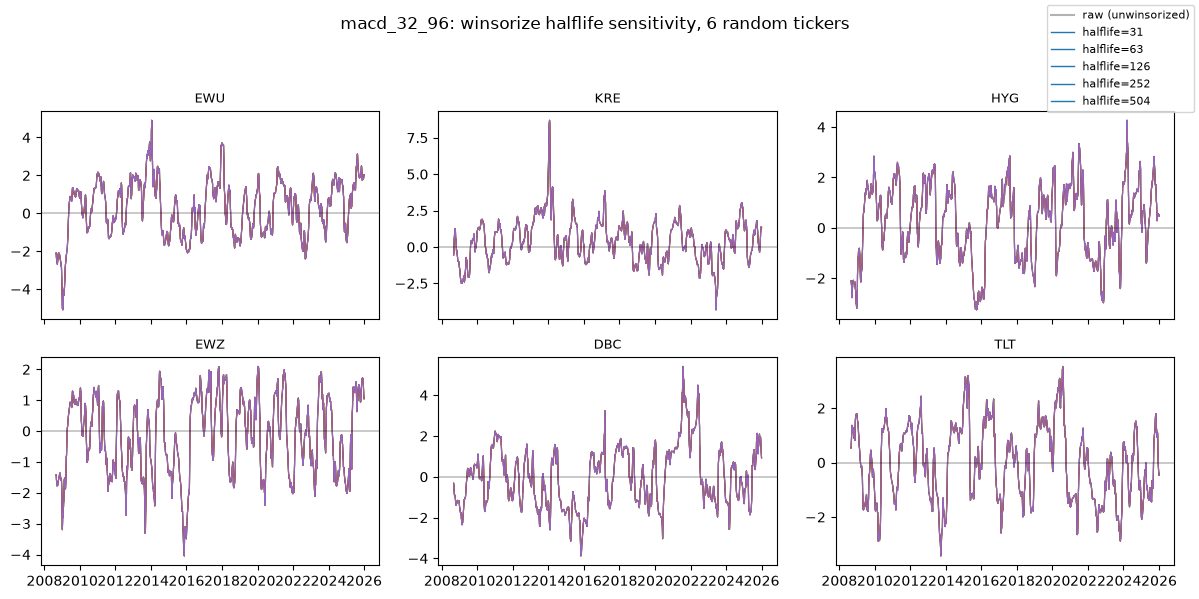

In [9]:
import numpy as np
from matplotlib.lines import Line2D

all_tickers = sorted(raw_panel.index.get_level_values("ticker").unique())
features = list(raw_panel.columns)

SAMPLE_SIZE = 6
sample_tickers = list(np.random.default_rng(0).choice(all_tickers, size=SAMPLE_SIZE, replace=False))
nrows, ncols = 2, 3

legend_handles = [Line2D([], [], color="black", alpha=0.3, label="raw (unwinsorized)")] + [
    Line2D([], [], linewidth=1, label=f"halflife={hl}") for hl in HALFLIVES
]

for feature in features:
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 4, nrows * 3), sharex=True)
    axes_flat = axes.flatten()

    for ax, ticker in zip(axes_flat, sample_tickers, strict=True):
        raw_series = raw_panel.xs(ticker, level="ticker")[feature]
        ax.plot(raw_series.index, raw_series.values, color="black", alpha=0.3, linewidth=0.8)

        for hl in HALFLIVES:
            clipped_series = winsorized_by_halflife[hl].xs(ticker, level="ticker")[feature]
            ax.plot(clipped_series.index, clipped_series.values, linewidth=0.8)

        ax.axhline(0, color="black", linewidth=0.3)
        ax.set_title(ticker, fontsize=9)

    fig.suptitle(f"{feature}: winsorize halflife sensitivity, {SAMPLE_SIZE} random tickers")
    fig.legend(handles=legend_handles, loc="upper right", fontsize=8)
    fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.93))


In [10]:
# `_Winsorizer.apply()` returns the input value unchanged (bit-for-bit) when
# it doesn't bind, so an exact `!=` is a safe way to detect "this point was
# clipped" -- restricted to points where the raw value is valid (NaNs
# propagate through winsorize as NaN, and NaN != NaN would otherwise be
# miscounted as "clipped").
valid = raw_panel.notna()

clip_rates = pd.DataFrame(
    {
        hl: ((winsorized_by_halflife[hl] != raw_panel) & valid).sum() / valid.sum()
        for hl in HALFLIVES
    }
)
clip_rates.columns.name = "halflife"
(clip_rates * 100).round(3)


halflife,31,63,126,252,504
mom_1,0.000,0.001,0.002,0.005,0.005
mom_21,0.000,0.000,0.000,0.000,0.000
mom_63,0.000,0.000,0.000,0.000,0.000
mom_126,0.000,0.000,0.000,0.000,0.000
mom_252,0.001,0.002,0.006,0.011,0.001
macd_8_24,0.000,0.000,0.000,0.000,0.000
macd_16_48,0.000,0.000,0.000,0.000,0.000
macd_32_96,0.000,0.000,0.001,0.000,0.000


In [11]:
baseline = winsorized_by_halflife[BASELINE_HALFLIFE]

sensitivity_rows = {}
for hl in HALFLIVES:
    if hl == BASELINE_HALFLIFE:
        continue
    other = winsorized_by_halflife[hl]
    row = {}
    for feature in raw_panel.columns:
        both_valid = baseline[feature].notna() & other[feature].notna()
        row[feature] = baseline.loc[both_valid, feature].corr(other.loc[both_valid, feature])
    sensitivity_rows[f"{BASELINE_HALFLIFE} vs {hl}"] = row

sensitivity_corr = pd.DataFrame(sensitivity_rows).T
sensitivity_corr.round(4)


,mom_1,mom_21,mom_63,mom_126,mom_252,macd_8_24,macd_16_48,macd_32_96
31 vs 63,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
31 vs 126,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
31 vs 252,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
31 vs 504,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
